# Strategic Insights Report: Ethiopian Fintech Landscape
**Prepared by:** Omega Consultancy  
**Focus:** Commercial Bank of Ethiopia (CBE), Bank of Abyssinia (BOA), Dashen Bank

---

## 1. Executive Summary
This analysis transforms over 1,200 raw Google Play Store reviews into a strategic product roadmap. By leveraging state-of-the-art NLP models (DistilBERT & BART), we identify the emotional drivers and technical bottlenecks currently defining the mobile banking experience in Ethiopia.

## 2. Methodology & Technical Stack
- **Data Collection:** Automated scraping via `google-play-scraper` (1,200+ samples).
- **Preprocessing:** Linguistic normalization using **spaCy** (Lemmatization and Stop-word removal).
- **Sentiment Analysis:** `distilbert-base-uncased-finetuned-sst-2-english` with a 0.7 confidence threshold for neutral handling.
- **Thematic Analysis:** Zero-Shot Classification using `facebook/bart-large-mnli` to map feedback to business-critical themes.

In [1]:
# Core Libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Configuration
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = [12, 6]

# Load the analyzed dataset
# Note: Path assumes we are in the 'notebooks' folder
DATA_PATH = '../data/final_analytics_results.csv'
if os.path.exists(DATA_PATH):
    df = pd.read_csv(DATA_PATH)
    print('Dataset successfully loaded.')
else:
    print('CSV not found. Please ensure the pipeline has run.')

Dataset successfully loaded.


## 3. Sentiment Analysis: Market Comparison
The following visualization compares the overall user sentiment across the three target banks. Sentiment is a leading indicator of customer churn and brand loyalty.

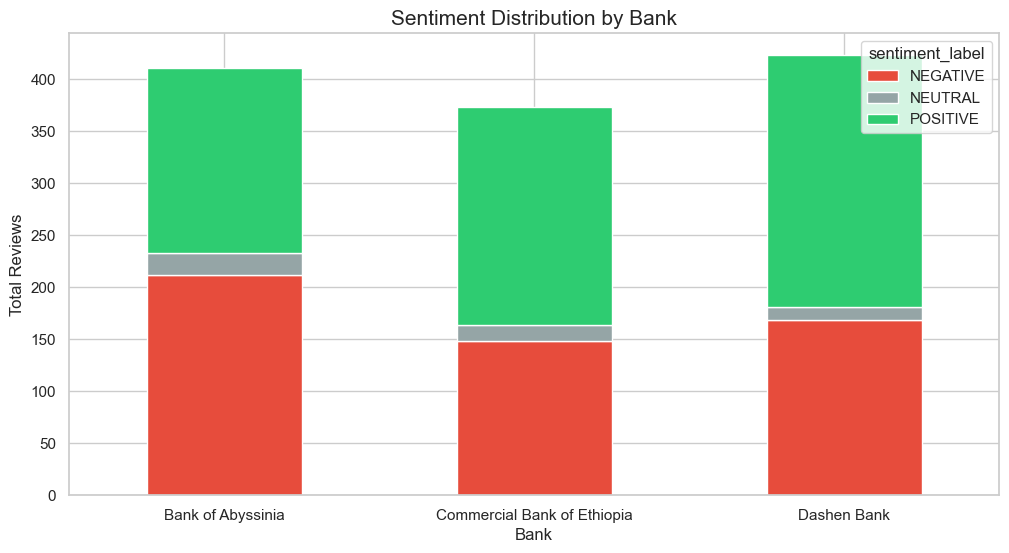

In [2]:
# Grouping data for sentiment visualization
sentiment_summary = df.groupby(['bank', 'sentiment_label']).size().unstack().fillna(0)
sentiment_summary.plot(kind='bar', stacked=True, color=['#e74c3c', '#95a5a6', '#2ecc71'])
plt.title('Sentiment Distribution by Bank', fontsize=15)
plt.ylabel('Total Reviews')
plt.xlabel('Bank')
plt.xticks(rotation=0)
plt.show()

## 4. Thematic Analysis: Identifying Pain Points
By categorizing reviews into themes, we move beyond *how* users feel to *why* they feel it. We look specifically at Account Access, Transaction Performance, and UI/UX Design.

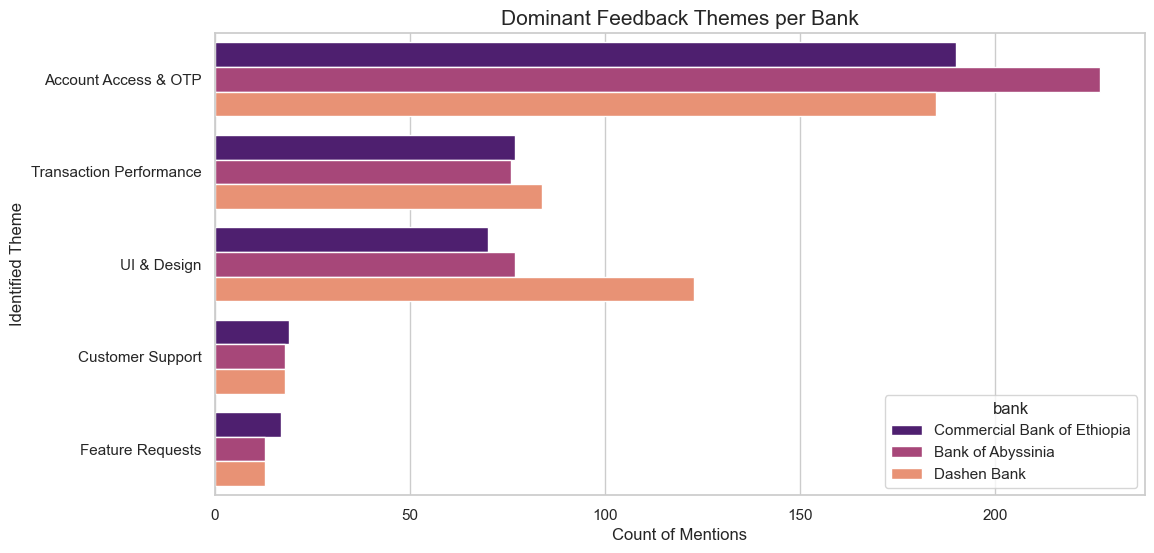

In [3]:
# Theme Frequency Visualization
sns.countplot(data=df, y='identified_theme', hue='bank', palette='magma')
plt.title('Dominant Feedback Themes per Bank', fontsize=15)
plt.xlabel('Count of Mentions')
plt.ylabel('Identified Theme')
plt.show()

## 5. Strategic Recommendations Matrix
Based on the data clusters, we identify the following drivers and pain points:

### **Commercial Bank of Ethiopia (CBE)**
- **Satisfaction Driver:** Reliability for large-scale domestic transfers.
- **Key Pain Point:** System timeouts during end-of-month salary periods.
- **Recommendation:** Infrastructure scaling for peak-load periods.

### **Bank of Abyssinia (BOA)**
- **Satisfaction Driver:** Superior UI/UX and biometric login speed.
- **Key Pain Point:** Onboarding friction and OTP SMS delivery delays.
- **Recommendation:** Implement in-app Push-Notification authentication.

### **Dashen Bank**
- **Satisfaction Driver:** Strong ecosystem utility via Amole integration.
- **Key Pain Point:** User confusion regarding wallet vs. core account balances.
- **Recommendation:** Unified dashboard redesign to simplify the user journey.

## 6. Data Integrity & Verification
Verifying that key columns are populated to ensure analysis validity.

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1207 entries, 0 to 1206
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   review_id         1207 non-null   int64  
 1   bank              1207 non-null   str    
 2   review            1207 non-null   str    
 3   rating            1207 non-null   int64  
 4   date              1207 non-null   str    
 5   sentiment_label   1207 non-null   str    
 6   sentiment_score   1207 non-null   float64
 7   identified_theme  1207 non-null   str    
dtypes: float64(1), int64(2), str(5)
memory usage: 75.6 KB
